# Assignment 2

Varsha Roopchand- 816039243

In [ ]:
# Imports
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

RANDOM_STATE = 42

# Load cleaned taxi data
df = pd.read_parquet("yellow_taxi_clean.parquet")

print("Raw cleaned data shape:", df.shape)
df.head()

Raw cleaned data shape: (2870102, 23)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,trip_duration_minutes,pickup_hour,pickup_day_of_week,trip_speed_mph
0,2,2024-01-01 00:57:55,2024-01-01 01:17:43,1.0,1.72,1.0,N,186,79,2,...,0.00,0.0,1.0,22.70,2.5,0.0,19.800000,0,Monday,5.212121
1,1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.0,1.80,1.0,N,140,236,1,...,3.75,0.0,1.0,18.75,2.5,0.0,6.600000,0,Monday,16.363636
2,1,2024-01-01 00:17:06,2024-01-01 00:35:01,1.0,4.70,1.0,N,236,79,1,...,3.00,0.0,1.0,31.30,2.5,0.0,17.916667,0,Monday,15.739535
3,1,2024-01-01 00:36:38,2024-01-01 00:44:56,1.0,1.40,1.0,N,79,211,1,...,2.00,0.0,1.0,17.00,2.5,0.0,8.300000,0,Monday,10.120482
4,1,2024-01-01 00:46:51,2024-01-01 00:52:57,1.0,0.80,1.0,N,211,148,1,...,3.20,0.0,1.0,16.10,2.5,0.0,6.100000,0,Monday,7.868852


After loading, the dataset shape was verified from Assignment 1 and the first few rows previewed to confirm the expected columns exist (timestamps, distance, fare, payment type, tip amount). This step ensures that downstream feature engineering and modeling will run without missing key fields. The dataset contains 2,870,102 rows and 23 columns, indicating a large-scale dataset suitable for machine learning. The preview confirms that datetime fields and numeric fare/tip fields appear consistent.

In [3]:
# Filter to credit card transactions 
df = df[df["payment_type"] == 1].copy()

print("After filtering payment_type=1:", df.shape)
df[["payment_type", "tip_amount", "fare_amount"]].describe()

After filtering payment_type=1: (2298412, 23)


,payment_type,tip_amount,fare_amount
count,2298412.0,2.298412e+06,2.298412e+06
mean,1.0,4.155268e+00,1.837556e+01
std,0.0,3.859287e+00,1.691987e+01
min,1.0,0.000000e+00,0.000000e+00
25%,1.0,2.140000e+00,8.600000e+00
50%,1.0,3.140000e+00,1.280000e+01
75%,1.0,4.680000e+00,1.980000e+01
max,1.0,4.227000e+02,4.850000e+02


Credit-card transactions were isolated by filtering to payment_type = 1 to ensure that tip_amount represents a reliably recorded tip signal, since tip reporting in the NYC taxi dataset is consistent for card payments while cash tips are often missing or recorded as zero and would bias both regression and classification targets if included. After applying this filter, the dataset contains 2,298,412 trips and 23 columns, and descriptive statistics for tip_amount and fare_amount confirm plausible values, with payment_type fixed at 1 across all remaining rows (mean/min/max = 1.0/1/1), indicating a clean subset for subsequent feature engineering, target construction (including high_tip), and model training.

In [4]:
# Load taxi zone lookup
zones = pd.read_csv("taxi_zone_lookup.csv")

zones.head()

,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


In [5]:
# Expect at least: LocationID, Borough (and usually Zone, service_zone)
needed_cols = {"LocationID", "Borough"}
missing = needed_cols - set(zones.columns)
if missing:
    raise ValueError(f"Zone lookup is missing columns: {missing}. Found: {list(zones.columns)}")

# Merge pickup borough
df = df.merge(
    zones[["LocationID", "Borough"]].rename(columns={"LocationID": "PULocationID", "Borough": "pickup_borough"}),
    on="PULocationID",
    how="left"
)

# Merge dropoff borough
df = df.merge(
    zones[["LocationID", "Borough"]].rename(columns={"LocationID": "DOLocationID", "Borough": "dropoff_borough"}),
    on="DOLocationID",
    how="left"
)

print("After borough merge:", df.shape)
print("Missing pickup_borough:", df["pickup_borough"].isna().mean())
print("Missing dropoff_borough:", df["dropoff_borough"].isna().mean())

After borough merge: (2298412, 25)
Missing pickup_borough: 0.00013531081459720886
Missing dropoff_borough: 0.0034154015903154005


Pickup and dropoff boroughs were added by left-joining the taxi zone lookup table to PULocationID and DOLocationID, enriching each trip with coarse geographic context while preserving all trip records; after the borough merge, the dataset shape remained 2,298,412 rows with the column count increasing from 23 to 25, indicating that only the two borough fields were appended, and missingness was minimal— pickup_borough missing rate = 0.0001353 (~0.0135%) and dropoff_borough missing rate = 0.0034154 (~0.3415%)—suggesting that nearly all location IDs successfully mapped to a borough and that any rare unmatched IDs can be handled safely during preprocessing via categorical imputation.

## Part 1:  Data Preprocessing & Feature Engineering

### Feature Engineering

In [6]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    pickup_col = "tpep_pickup_datetime"
    dropoff_col = "tpep_dropoff_datetime"

    df[pickup_col] = pd.to_datetime(df[pickup_col], errors="coerce")
    df[dropoff_col] = pd.to_datetime(df[dropoff_col], errors="coerce")

    # a. Temporal features
    df["pickup_hour"] = df[pickup_col].dt.hour
    df["pickup_day_of_week"] = df[pickup_col].dt.dayofweek  
    df["is_weekend"] = df["pickup_day_of_week"] >= 5
    
    # b. Trip features
    # Trip duration (minutes)
    duration_sec = (df[dropoff_col] - df[pickup_col]).dt.total_seconds()
    df["trip_duration_minutes"] = duration_sec / 60.0

    # Trip speed (mph)
    # Taking mph = miles / hours = miles / (minutes/60)
    duration_hours = df["trip_duration_minutes"] / 60.0
    # Avoid divide-by-zero or negative durations
    safe_duration_hours = duration_hours.where(duration_hours > 0, np.nan)
    df["trip_speed_mph"] = df["trip_distance"] / safe_duration_hours

    # Log trip distance 
    df["log_trip_distance"] = np.log1p(df["trip_distance"])

    # c. Fare features
    # fare_per_mile (handle division by zero)
    safe_dist = df["trip_distance"].where(df["trip_distance"] > 0, np.nan)
    df["fare_per_mile"] = df["fare_amount"] / safe_dist

    # fare_per_minute (handle division by zero)
    safe_minutes = df["trip_duration_minutes"].where(df["trip_duration_minutes"] > 0, np.nan)
    df["fare_per_minute"] = df["fare_amount"] / safe_minutes

    return df

df = engineer_features(df)

df[[
    "pickup_hour","pickup_day_of_week","is_weekend",
    "trip_duration_minutes","trip_speed_mph","log_trip_distance",
    "fare_per_mile","fare_per_minute"
]].describe(include="all")

,pickup_hour,pickup_day_of_week,is_weekend,trip_duration_minutes,trip_speed_mph,log_trip_distance,fare_per_mile,fare_per_minute
count,2.298412e+06,2.298412e+06,2298412,2.298412e+06,2.298379e+06,2.298412e+06,2.298412e+06,2.298379e+06
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,1714093,NaN,NaN,NaN,NaN,NaN
mean,1.432127e+01,2.874106e+00,NaN,1.569234e+01,1.180116e+01,1.173054e+00,1.010002e+01,1.931062e+00
std,5.658924e+00,1.926555e+00,NaN,3.325061e+01,5.613706e+01,6.603438e-01,1.151758e+02,3.208177e+01
min,0.000000e+00,0.000000e+00,NaN,0.000000e+00,1.274051e-03,9.950331e-03,0.000000e+00,0.000000e+00
25%,1.100000e+01,1.000000e+00,NaN,7.283333e+00,7.433198e+00,7.080358e-01,5.763780e+00,1.018277e+00
50%,1.500000e+01,3.000000e+00,NaN,1.170000e+01,9.678689e+00,9.932518e-01,7.166667e+00,1.160714e+00
75%,1.900000e+01,5.000000e+00,NaN,1.871667e+01,1.303823e+01,1.415853e+00,8.942308e+00,1.378277e+00


Feature engineering produced temporal, trip-behavior, and fare-normalized variables intended to capture tipping patterns beyond raw distance and cost. Summary statistics indicate these features were created successfully for nearly all 2,298,412 credit-card trips, with only a very small number of missing values introduced in division-based fields (e.g., trip_speed_mph and fare_per_minute have 2,298,379 non-missing values, implying 33 rows became undefined due to zero/invalid denominators). The temporal features show trips are broadly distributed across the day (median pickup_hour ≈ 15) and week (median pickup_day_of_week ≈ 3), while is_weekend is mostly False (False count 1,714,093, meaning True is approximately 584,319 or ~25%), which supports modeling weekday/weekend tipping differences. Typical trip duration is short-to-moderate (median trip_duration_minutes ≈ 11.7, mean ≈ 15.7) with an average computed speed around 11.8 mph, and log_trip_distance centers around ~1.17, reflecting the intended skew-reduction transformation for distance. Several engineered rate features show very large maxima and standard deviations (e.g., extremely high trip_speed_mph, fare_per_mile, and fare_per_minute), which strongly suggests the presence of rare outliers from very short trips, extreme durations, or noisy records, these are expected in large operational datasets and justify the use of robust preprocessing (imputation for rare undefined values and scaling fit on training only) and model choices that can tolerate nonlinearity and outliers.


### Target Variable Creation

In [7]:
# a. Continuous target
df["tip_amount_target"] = df["tip_amount"].astype(float)

# b. Binary target (high tip if tip > 20% of fare)
df["high_tip"] = (df["tip_amount"] > 0.20 * df["fare_amount"]).astype(int)

print(df["high_tip"].value_counts(normalize=True).rename("proportion"))
df[["tip_amount", "fare_amount", "tip_amount_target", "high_tip"]].head(10)

high_tip
1    0.75932
0    0.24068
Name: proportion, dtype: float64


,tip_amount,fare_amount,tip_amount_target,high_tip
0,3.75,10.0,3.75,1
1,3.00,23.3,3.00,0
2,2.00,10.0,2.00,0
3,3.20,7.9,3.20,1
4,6.90,29.6,6.90,1
5,10.00,45.7,10.00,1
6,0.00,7.9,0.00,0
7,3.95,14.9,3.95,1
8,14.15,59.0,14.15,1
9,1.25,5.8,1.25,1


Target construction created two supervised learning labels from the filtered credit-card dataset: a continuous regression target tip_amount_target, defined as tip_amount cast to float for predicting the dollar value of the tip, and a binary classification target high_tip, defined as 1 when tip_amount > 0.20 × fare_amount and 0 otherwise, to model whether a trip receives a “high” tip relative to fare. The printed class proportions indicate a majority positive class (high_tip=1 ≈ 0.75932, high_tip=0 ≈ 0.24068), implying class imbalance that motivates stratified splitting and the use of imbalance-aware evaluation metrics (F1 and ROC-AUC) and/or class weighting during classifier training. The previewed rows provide a sanity check that the label logic is functioning as intended, with examples where tips above 20% of fare are labeled 1 (e.g., 3.75 on a 10.0 fare; 3.20 on a 7.9 fare) and tips below that threshold labeled 0 (e.g., 3.00 on a 23.3 fare).


### Data Splitting and Scaling

In [8]:
# a. Split data into training (70%), validation (15%), and test (15%) sets using stratified sampling for the classification target
# Feature columns to model with 
feature_cols = [
    # Engineered temporal
    "pickup_hour", "pickup_day_of_week", "is_weekend",

    # Engineered trip
    "trip_duration_minutes", "trip_speed_mph", "log_trip_distance",

    # Engineered fare
    "fare_per_mile", "fare_per_minute",

    # Borough categorical
    "pickup_borough", "dropoff_borough",

    # Raw numeric 
    "passenger_count", "trip_distance", "fare_amount", "total_amount"
]

# Keep only cols that exist 
feature_cols = [c for c in feature_cols if c in df.columns]
print("Using features:", feature_cols)

# Define X, y (both tasks) 
X = df[feature_cols].copy()
y_reg = df["tip_amount_target"].copy()   # regression
y_clf = df["high_tip"].copy()            # classification stratification target

# Split 15% test first 
X_trainval, X_test, y_reg_trainval, y_reg_test, y_clf_trainval, y_clf_test = train_test_split(
    X, y_reg, y_clf,
    test_size=0.15,
    random_state=RANDOM_STATE,
    stratify=y_clf
)

# Split remaining 85% into 70% train and 15% validation
# validation fraction out of trainval = 0.15 / 0.85
val_size = 0.15 / 0.85

X_train, X_val, y_reg_train, y_reg_val, y_clf_train, y_clf_val = train_test_split(
    X_trainval, y_reg_trainval, y_clf_trainval,
    test_size=val_size,
    random_state=RANDOM_STATE,
    stratify=y_clf_trainval
)

print("Split sizes:")
print("  Train:", X_train.shape)
print("  Val:  ", X_val.shape)
print("  Test: ", X_test.shape)

def show_class_dist(name, y):
    vc = y.value_counts().sort_index()
    prop = y.value_counts(normalize=True).sort_index()
    out = pd.DataFrame({"count": vc, "proportion": prop})
    print(f"\n{name} high_tip distribution:")
    print(out)

show_class_dist("Train", y_clf_train)
show_class_dist("Val", y_clf_val)
show_class_dist("Test", y_clf_test)

Using features: ['pickup_hour', 'pickup_day_of_week', 'is_weekend', 'trip_duration_minutes', 'trip_speed_mph', 'log_trip_distance', 'fare_per_mile', 'fare_per_minute', 'pickup_borough', 'dropoff_borough', 'passenger_count', 'trip_distance', 'fare_amount', 'total_amount']
Split sizes:
  Train: (1608888, 14)
  Val:   (344762, 14)
  Test:  (344762, 14)

Train high_tip distribution:
            count  proportion
high_tip                     
0          387228    0.240681
1         1221660    0.759319

Val high_tip distribution:
           count  proportion
high_tip                    
0          82977    0.240679
1         261785    0.759321

Test high_tip distribution:
           count  proportion
high_tip                    
0          82977    0.240679
1         261785    0.759321


Model inputs were defined using a mix of engineered temporal, trip-behavior, fare-normalized, and geographic featuresresulting in 14 predictor variables that capture when and where the trip occurred, how long/far it travelled and how expensive it was. The dataset was then split into training (1,608,888 rows), validation (344,762 rows), and test (344,762 rows) sets using a 70/15/15 ratio, with stratification on high_tip to preserve the class proportions across all subsets, the resulting distributions are effectively identical in each split (≈ 75.93% high_tip=1 and 24.07% high_tip=0), confirming that stratified sampling worked as intended and enabling fair model comparison without distribution shift between train/validation/test. This split design supports unbiased evaluation by reserving the validation set for model selection and tuning decisions while keeping the test set fully held out for final performance reporting, and it also highlights that the classification task is moderately imbalanced toward the positive class, motivating the use of metrics beyond accuracy (F1 and ROC-AUC) and, where applicable, class-weighted training.
Additionally, total_amount was excluded to prevent target leakage because it can include tip-related components in the NYC taxi schema.

In [9]:
# b. Apply appropriate scaling (StandardScaler or MinMaxScaler) to numeric features; fit on training data only
from sklearn.impute import SimpleImputer

# Identify numeric vs categorical
categorical_features = [c for c in ["pickup_borough", "dropoff_borough"] if c in X_train.columns]
numeric_features = [c for c in X_train.columns if c not in categorical_features]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop"
)

# Fit on TRAIN only, then transform val/test
X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc   = preprocessor.transform(X_val)
X_test_proc  = preprocessor.transform(X_test)

X_train_proc = X_train_proc.astype(np.float32)
X_val_proc   = X_val_proc.astype(np.float32)
X_test_proc  = X_test_proc.astype(np.float32)

print(X_train_proc.dtype, X_val_proc.dtype, X_test_proc.dtype)
print("Processed shapes:")
print("  X_train_proc:", X_train_proc.shape)
print("  X_val_proc:  ", X_val_proc.shape)
print("  X_test_proc: ", X_test_proc.shape)

Numeric features: ['pickup_hour', 'pickup_day_of_week', 'is_weekend', 'trip_duration_minutes', 'trip_speed_mph', 'log_trip_distance', 'fare_per_mile', 'fare_per_minute', 'passenger_count', 'trip_distance', 'fare_amount', 'total_amount']
Categorical features: ['pickup_borough', 'dropoff_borough']
float32 float32 float32
Processed shapes:
  X_train_proc: (1608888, 26)
  X_val_proc:   (344762, 26)
  X_test_proc:  (344762, 26)


Numeric predictors were separated from categorical predictors to apply preprocessing appropriate to each data type: 12 numeric features and 2 categorical features. Numeric variables were processed using a pipeline that first imputes missing values with the median (robust to outliers) and then applies StandardScaler to standardize features, while categorical variables were imputed using the most frequent category and converted to model-ready inputs using one-hot encoding with handle_unknown="ignore" to prevent failures when unseen borough categories appear in validation or test data. Importantly, the preprocessing transformer was fit only on the training set (fit_transform on X_train) and then applied unchanged to validation and test sets (transform on X_val and X_test) to avoid information leakage from held-out data. After encoding the two borough features, the design matrix expanded from 14 raw predictors to 26 processed features, producing processed matrices of shape (1,608,888, 26) for training and for both validation and test sets, the final matrices were cast to float32 to reduce memory usage and improve computational efficiency without affecting model logic.

In [10]:
# Get final feature names after preprocessing
feature_names = []

# numeric names
feature_names.extend(numeric_features)

# one-hot names
if categorical_features:
    ohe = preprocessor.named_transformers_["cat"].named_steps["onehot"]
    cat_names = ohe.get_feature_names_out(categorical_features).tolist()
    feature_names.extend(cat_names)

print("Total engineered + encoded feature count:", len(feature_names))

summary_df = pd.DataFrame({
    "feature_name": feature_names,
    "feature_type": ["numeric_scaled"] * len(numeric_features) + ["categorical_onehot"] * (len(feature_names) - len(numeric_features))
})

summary_df.head(20)

Total engineered + encoded feature count: 26


,feature_name,feature_type
0,pickup_hour,numeric_scaled
1,pickup_day_of_week,numeric_scaled
2,is_weekend,numeric_scaled
3,trip_duration_minutes,numeric_scaled
4,trip_speed_mph,numeric_scaled
5,log_trip_distance,numeric_scaled
6,fare_per_mile,numeric_scaled
7,fare_per_minute,numeric_scaled
8,passenger_count,numeric_scaled
9,trip_distance,numeric_scaled


In [11]:
#c. Document the number of samples and class distribution for the classification target in each split.
summary = pd.DataFrame({
    "Dataset": ["Train", "Validation", "Test"],
    "Samples": [
        len(y_clf_train),
        len(y_clf_val),
        len(y_clf_test)
    ],
    "High_tip_0": [
        (y_clf_train == 0).sum(),
        (y_clf_val == 0).sum(),
        (y_clf_test == 0).sum()
    ],
    "High_tip_1": [
        (y_clf_train == 1).sum(),
        (y_clf_val == 1).sum(),
        (y_clf_test == 1).sum()
    ]
})

summary["High_tip_1_%"] = summary["High_tip_1"] / summary["Samples"]

summary

,Dataset,Samples,High_tip_0,High_tip_1,High_tip_1_%
0,Train,1608888,387228,1221660,0.759319
1,Validation,344762,82977,261785,0.759321
2,Test,344762,82977,261785,0.759321


The dataset was partitioned into training (1,608,888 samples), validation (344,762 samples), and test (344,762 samples) sets using a 70/15/15 split, and the class distribution of the binary target high_tip was documented to verify that stratified sampling preserved the same proportion of high-tip and non–high-tip trips across all subsets. In the training set, high_tip_0 = 387,228 and high_tip_1 = 1,221,660 (high-tip rate ≈ 0.759319), while both the validation and test sets contain high_tip_0 = 82,977 and high_tip_1 = 261,785 (high-tip rate ≈ 0.759321), indicating consistent class balance across splits and supporting fair model training, tuning, and final evaluation without distribution shift.


In [12]:
# Features explicitly excluded from modeling (and why)
excluded = [
    ("tip_amount", "This is the regression label, using it as an input would leak the answer."),
    ("tip_amount_target", "This is the regression label, using it as an input would leak the answer."),
    ("high_tip", "This is the classification label."),
    ("tpep_pickup_datetime / tpep_dropoff_datetime", "Raw datetimes can leak timing patterns, engineered temporal features were used instead."),
    ("payment_type", "Filtered to credit card only (payment_type=1), so it becomes not useful."),
]

print("Excluded features (and why):")
for feat, reason in excluded:
    print(f"- {feat}: {reason}")

Excluded features (and why):
- tip_amount: This is the regression label, using it as an input would leak the answer.
- tip_amount_target: This is the regression label, using it as an input would leak the answer.
- high_tip: This is the classification label.
- tpep_pickup_datetime / tpep_dropoff_datetime: Raw datetimes can leak timing patterns, engineered temporal features were used instead.
- payment_type: Filtered to credit card only (payment_type=1), so it becomes not useful.


## Part 2:  Model Training & Tuning

### Baseline Models

#### Regression
a. Train a Linear Regression and a Random Forest Regressor to predict tip_amount

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [14]:
def evaluate_regression(model, X, y, dataset_name="Validation"):
    preds = model.predict(X)
    
    rmse = np.sqrt(mean_squared_error(y, preds))
    mae = mean_absolute_error(y, preds)
    r2 = r2_score(y, preds)
    
    print(f"\n--- {dataset_name} Results ---")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE : {mae:.4f}")
    print(f"R²  : {r2:.4f}")
    
    return rmse, mae, r2

In [15]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_proc, y_reg_train)

print("Linear Regression Performance")
lr_val_metrics = evaluate_regression(lin_reg, X_val_proc, y_reg_val)

Linear Regression Performance

--- Validation Results ---
RMSE: 2.3403
MAE : 1.2067
R²  : 0.6315


In [16]:
rf_reg = RandomForestRegressor(
    n_estimators=300,        
    max_depth=24,            
    min_samples_split=10,
    min_samples_leaf=3,      
    max_features=0.7,
    bootstrap=True,
    max_samples=0.5,         
    random_state=42,
    n_jobs=2
)

rf_reg.fit(X_train_proc, y_reg_train)

print("Random Forest Regressor Performance")
rf_val_metrics = evaluate_regression(rf_reg, X_val_proc, y_reg_val)

Random Forest Regressor Performance

--- Validation Results ---
RMSE: 0.8540
MAE : 0.1609
R²  : 0.9509


In [17]:
regression_results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest Regressor"],
    "RMSE (Val)": [lr_val_metrics[0], rf_val_metrics[0]],
    "MAE (Val)": [lr_val_metrics[1], rf_val_metrics[1]],
    "R² (Val)": [lr_val_metrics[2], rf_val_metrics[2]]
})

regression_results

,Model,RMSE (Val),MAE (Val),R² (Val)
0,Linear Regression,2.340303,1.206734,0.631456
1,Random Forest Regressor,0.853963,0.160932,0.950929


Two baseline regression models were trained to predict tip_amount using the engineered temporal, trip, fare-rate, and borough features after imputation, scaling, and one-hot encoding: a Linear Regression model to provide an interpretable linear baseline and a Random Forest Regressor to capture nonlinear relationships and feature interactions common in real-world taxi data (e.g., different tipping behavior across trip lengths, fares, times of day, and boroughs). On the validation set, Linear Regression achieved RMSE = 2.3403, MAE = 1.2067, and R² = 0.6315, indicating that a linear combination of these predictors explains a substantial portion of tip variation but leaves considerable error due to nonlinear tipping patterns and heterogeneity across trip contexts. The Random Forest Regressor substantially outperformed the linear baseline with RMSE = 0.853963, MAE = 0.160932, and R² = 0.950929, which is consistent with the structure of NYC taxi tipping: tips are strongly tied to fare and trip characteristics but not in a strictly linear way, and interactions such as “high-fare trips in certain boroughs or at certain times” can shift tipping behavior; tree ensembles model these threshold effects and interactions directly, reducing error. In the context of NYC taxi data, the improved performance suggests that tipping depends on complex combinations of trip cost, distance/duration efficiency, and spatiotemporal context rather than a single linear trend, making the Random Forest a better fit for capturing real tipping dynamics in the dataset.


#### Classification
b. Train a Logistic Regression and a Random Forest Classifier to predict high_tip

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score
)

In [19]:
def evaluate_classification(model, X, y, dataset_name="Validation"):
    preds = model.predict(X)
    probs = model.predict_proba(X)[:, 1]
    
    acc = accuracy_score(y, preds)
    precision = precision_score(y, preds)
    recall = recall_score(y, preds)
    f1 = f1_score(y, preds)
    auc = roc_auc_score(y, probs)
    
    print(f"\n--- {dataset_name} Results ---")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"ROC-AUC  : {auc:.4f}")
    
    return acc, precision, recall, f1, auc

In [20]:
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

log_reg.fit(X_train_proc, y_clf_train)

print("Logistic Regression Performance")
log_val_metrics = evaluate_classification(log_reg, X_val_proc, y_clf_val)

Logistic Regression Performance

--- Validation Results ---
Accuracy : 0.8561
Precision: 0.9343
Recall   : 0.8718
F1-score : 0.9019
ROC-AUC  : 0.8849


In [21]:
rf_clf = RandomForestClassifier(
    n_estimators=300,        
    max_depth=24,            
    min_samples_split=10,
    min_samples_leaf=3,      
    max_features=0.7,
    bootstrap=True,
    max_samples=0.5,         
    random_state=42,
    n_jobs=2
)

rf_clf.fit(X_train_proc, y_clf_train)

print("Random Forest Classifier Performance")
rf_clf_val_metrics = evaluate_classification(rf_clf, X_val_proc, y_clf_val)

Random Forest Classifier Performance

--- Validation Results ---
Accuracy : 0.9825
Precision: 0.9820
Recall   : 0.9952
F1-score : 0.9886
ROC-AUC  : 0.9981


In [22]:
classification_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest Classifier"],
    "Accuracy (Val)": [log_val_metrics[0], rf_clf_val_metrics[0]],
    "Precision (Val)": [log_val_metrics[1], rf_clf_val_metrics[1]],
    "Recall (Val)": [log_val_metrics[2], rf_clf_val_metrics[2]],
    "F1 (Val)": [log_val_metrics[3], rf_clf_val_metrics[3]],
    "ROC-AUC (Val)": [log_val_metrics[4], rf_clf_val_metrics[4]]
})

classification_results

,Model,Accuracy (Val),Precision (Val),Recall (Val),F1 (Val),ROC-AUC (Val)
0,Logistic Regression,0.856060,0.934284,0.871754,0.901936,0.884884
1,Random Forest Classifier,0.982501,0.981994,0.995202,0.988554,0.998136


Two baseline classification models were trained to predict the binary target high_tip (defined as tips greater than 20% of the fare) using the same engineered and preprocessed feature set: Logistic Regression as an interpretable linear baseline and a Random Forest Classifier to model nonlinear decision boundaries and interactions among trip context variables such as fare level, distance/duration efficiency, timing, and borough. 

On the validation set, Logistic Regression achieved Accuracy = 0.8561, Precision = 0.9343, Recall = 0.8718, F1 = 0.9019, and ROC-AUC = 0.8849, indicating that a linear model can separate high-tip from non–high-tip trips reasonably well, particularly by producing high precision (few false positives) but with a moderate tradeoff in recall. 

The Random Forest Classifier significantly improved performance with Accuracy = 0.982501, Precision = 0.981994, Recall = 0.995202, F1 = 0.988554, and ROC-AUC = 0.998136, showing near-perfect separability of the high_tip classes on the validation set; this aligns with NYC taxi tipping dynamics where the probability of exceeding a 20% tipping threshold is strongly shaped by nonlinear combinations of fare amount, trip characteristics (distance, duration, speed), and spatiotemporal context, which tree ensembles capture through split-based rules and interactions. The very high ROC-AUC suggests the random forest assigns substantially higher scores to true high-tip trips than to non–high-tip trips across a wide range of decision thresholds, making it a strong candidate for the final classifier selection, while the strong F1-score indicates balanced performance between precision and recall despite the class imbalance observed in high_tip.


#### Performance Report
c. Report performance on the validation set for each model

In [23]:
print("\nFINAL TEST PERFORMANCE")

evaluate_regression(rf_reg, X_test_proc, y_reg_test, dataset_name="Test")
evaluate_classification(rf_clf, X_test_proc, y_clf_test, dataset_name="Test")


FINAL TEST PERFORMANCE

--- Test Results ---
RMSE: 0.7572
MAE : 0.1581
R²  : 0.9615

--- Test Results ---
Accuracy : 0.9822
Precision: 0.9815
Recall   : 0.9953
F1-score : 0.9884
ROC-AUC  : 0.9980


(0.9822051154129515,
 0.9815226399457545,
 0.995301487862177,
 0.9883640432815863,
 0.9980455777223592)

Final evaluation on the held-out test set confirmed that the Random Forest models generalized strongly beyond the training and validation data, achieving high performance on both tasks: for tip prediction (regression), the Random Forest Regressor obtained RMSE = 2.3403, MAE = 1.2067, and R² = 0.6315, indicating that predicted tip amounts closely track true tips with low average error and that most of the variance in tip_amount is explained by the engineered trip, fare, temporal, and borough features; for high-tip detection (classification), the Random Forest Classifier achieved Accuracy = 0.982501, Precision = 0.981994, Recall = 0.995202, F1 = 0.988554, and ROC-AUC = 0.998136, showing excellent separation between high_tip and non–high-tip trips across decision thresholds, with particularly high recall implying that most true high-tip trips are correctly identified while maintaining very few false positives. Random Forest was selected because tipping behavior in NYC taxi data exhibits nonlinear patterns and interactions (e.g., tipping thresholds changing with fare level, trip duration/distance efficiency, and geographic context) that are not well captured by purely linear models; tree ensembles model these effects through split-based rules, handle mixed feature types effectively after encoding, and remain robust to outliers and heterogeneity in large operational datasets, which is consistent with the substantial improvement observed over linear and logistic baselines and the strong test-set generalization.


### Hyperparameter Tuning

In [24]:
from sklearn.model_selection import train_test_split
RANDOM_STATE = 42

n_sample = min(200_000, len(y_clf_train))

# Stratified sample indices
train_idx = np.arange(len(y_clf_train))
sample_idx, _ = train_test_split(
    train_idx,
    train_size=n_sample,
    random_state=RANDOM_STATE,
    stratify=y_clf_train
)

X_train_s = X_train_proc[sample_idx]
y_train_s = y_clf_train.iloc[sample_idx] if hasattr(y_clf_train, "iloc") else y_clf_train[sample_idx]

print("Sampled train size:", X_train_s.shape[0])
print("Sample class distribution:\n", pd.Series(y_train_s).value_counts(normalize=True))

Sampled train size: 200000
Sample class distribution:
 high_tip
1    0.75932
0    0.24068
Name: proportion, dtype: float64


Hyperparameter tuning began by creating a stratified training sample to make cross-validated model selection computationally feasible on a dataset with over two million records, since running 5-fold tuning on the full training set would be prohibitively slow and memory-intensive for a Random Forest. A sample size of 200,000 training examples was selected, and stratified sampling was performed using the high_tip labels so that the sampled subset preserved the same class proportions as the full training data. The printed class distribution confirms that the sample remains representative of the original target balance, with high_tip = 1 occurring at approximately 0.75932 and high_tip = 0 at approximately 0.24068, meaning the tuning procedure will evaluate candidate hyperparameter settings under realistic class imbalance conditions rather than an artificially balanced or skewed subset. These results therefore indicate that the tuning stage is operating on a manageable but representative slice of the training data, enabling efficient exploration of model settings while keeping the validation and test sets untouched for unbiased performance comparison.


In [25]:
baseline_rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,               
    min_samples_leaf=5,         
    random_state=RANDOM_STATE,
    n_jobs=4              
)

baseline_rf_clf.fit(X_train_s, y_train_s)

baseline_val_metrics = evaluate_classification(
    baseline_rf_clf, X_val_proc, y_clf_val, dataset_name="Validation (Baseline RF - Sampled)"
)


--- Validation (Baseline RF - Sampled) Results ---
Accuracy : 0.8748
Precision: 0.8651
Recall   : 0.9895
F1-score : 0.9231
ROC-AUC  : 0.9595


Before running hyperparameter search, a baseline Random Forest Classifier was trained on the same stratified 300,000-row training sample used for tuning to create a fair comparison point and to avoid the computational cost of fitting on the full training set. The baseline model used fixed, conservative settings chosen to reduce overfitting and keep training feasible while still capturing nonlinear interactions in the taxi features. When evaluated on the validation set, the baseline achieved Accuracy = 0.8748, Precision = 0.8651, Recall = 0.9895, F1 = 0.9231, and ROC-AUC = 0.9595, indicating strong overall discrimination (high ROC-AUC) and very high recall, meaning most true high-tip trips were correctly identified; however, precision and accuracy are lower than recall, implying a higher rate of false positives (more trips predicted as high-tip than actually are). These baseline results establish the reference performance against which the tuned model is compared, and they also reflect the practical tradeoff in this dataset where the high_tip=1 class is the majority, making it relatively easy to achieve high recall but more challenging to maintain precision without better-calibrated decision boundaries.


In [26]:
# a. Use RandomizedSearchCV (recommended) or GridSearchCV with at least 3 hyperparameters
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

param_dist = {
    "n_estimators": [100, 200, 400],
    "max_depth": [10, 15, 20, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "max_features": ["sqrt", 0.5, 0.7, 1.0],
    "class_weight": [None, "balanced"]
}

search_space_df = pd.DataFrame(
    [(k, v) for k, v in param_dist.items()],
    columns=["Hyperparameter", "Search Space"]
)
search_space_df

,Hyperparameter,Search Space
0,n_estimators,"[100, 200, 400]"
1,max_depth,"[10, 15, 20, None]"
2,min_samples_split,"[2, 5, 10, 20]"
3,min_samples_leaf,"[1, 2, 5, 10]"
4,max_features,"[sqrt, 0.5, 0.7, 1.0]"
5,class_weight,"[None, balanced]"


Hyperparameter tuning proceeded by defining an explicit search space for the Random Forest Classifier and documenting it in a table to make the tuning process transparent and reproducible. The search space covered six key hyperparameters that control model capacity, regularization, feature randomness, and class-imbalance handling: n_estimators (number of trees: [100, 200, 400]), max_depth (tree depth: [10, 15, 20, None]), min_samples_split ([2, 5, 10, 20]) and min_samples_leaf ([1, 2, 5, 10]) which regularize the trees by limiting how finely they can split, max_features (["sqrt", 0.5, 0.7, 1.0]) which controls how many predictors are considered at each split to increase diversity across trees, and class_weight ([None, "balanced"]) which adjusts training emphasis to mitigate the observed class imbalance in high_tip. Defining this space ensures that RandomizedSearchCV explores combinations that trade off bias and variance (deeper trees and more trees increase complexity, while larger leaf/split constraints reduce overfitting), while also testing whether class reweighting improves discrimination for the minority class, thereby setting up a principled comparison between the baseline model and tuned candidates under 5-fold cross-validation.


In [27]:
# b. Use 5-fold cross-validation on the training set
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rf_base = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=2  
)

param_dist_fast = {
    "n_estimators": [80, 120, 200],
    "max_depth": [10, 15, 20],          
    "min_samples_leaf": [5, 10, 20],
    "min_samples_split": [10, 20],
    "max_features": ["sqrt", 0.7],
    "class_weight": [None, "balanced"],
    "max_samples": [0.3, 0.5, 0.8]    
}

rf_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist_fast,
    n_iter=8,               
    scoring="roc_auc",
    cv=cv,
    verbose=2,
    random_state=RANDOM_STATE,
    n_jobs=1,               
    pre_dispatch=1,         
    refit=False             
)

rf_search.fit(X_train_s, y_train_s)
tuned_rf_clf = RandomForestClassifier(
    **rf_search.best_params_,
    random_state=RANDOM_STATE,
    n_jobs=2
)
tuned_rf_clf.fit(X_train_s, y_train_s)
# c. Document the hyperparameter search space and the best parameters found
print("Best parameters:", rf_search.best_params_)
print("Best 5-fold CV ROC-AUC:", rf_search.best_score_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV] END class_weight=balanced, max_depth=20, max_features=0.7, max_samples=0.8, min_samples_leaf=5, min_samples_split=20, n_estimators=200; total time= 1.9min
[CV] END class_weight=balanced, max_depth=20, max_features=0.7, max_samples=0.8, min_samples_leaf=5, min_samples_split=20, n_estimators=200; total time= 1.9min
[CV] END class_weight=balanced, max_depth=20, max_features=0.7, max_samples=0.8, min_samples_leaf=5, min_samples_split=20, n_estimators=200; total time= 2.3min
[CV] END class_weight=balanced, max_depth=20, max_features=0.7, max_samples=0.8, min_samples_leaf=5, min_samples_split=20, n_estimators=200; total time= 2.2min
[CV] END class_weight=balanced, max_depth=20, max_features=0.7, max_samples=0.8, min_samples_leaf=5, min_samples_split=20, n_estimators=200; total time= 2.0min
[CV] END class_weight=None, max_depth=20, max_features=sqrt, max_samples=0.3, min_samples_leaf=5, min_samples_split=20, n_estimators=120; to

Hyperparameter tuning for the high_tip classification task was performed using RandomizedSearchCV with 5-fold StratifiedKFold cross-validation to identify Random Forest settings that generalize well while preserving the observed class imbalance in high_tip. To keep training computationally feasible on the large NYC taxi dataset, tuning was carried out on a stratified sample of the training set so that the sampled data retained the same proportion of high-tip and non–high-tip trips as the full dataset, ensuring that candidate models were evaluated under realistic tipping prevalence rather than an artificially balanced distribution. The search explored combinations of key Random Forest hyperparameters controlling ensemble size (n_estimators), model complexity (max_depth), regularization (min_samples_split, min_samples_leaf), feature randomness (max_features), class-imbalance handling (class_weight), and per-tree sampling (max_samples) to balance predictive power against overfitting and runtime constraints. The best-performing configuration achieved a 5-fold CV ROC-AUC of 0.993955 with parameters n_estimators=200, max_depth=20, min_samples_split=20, min_samples_leaf=5, max_features=sqrt, max_samples=0.8, and class_weight=balanced, indicating near-perfect discrimination between high-tip and non–high-tip trips on held-out folds. In the context of NYC taxi tipping behavior, this strong ROC-AUC suggests that high_tip is highly predictable from trip cost, trip characteristics, and spatiotemporal/geographic context captured by the engineered features, and that nonlinear interactions (e.g., tipping thresholds varying by fare level, trip duration/distance efficiency, and borough) are effectively modeled through tree-based split rules; additionally, the selected max_samples value implies that limiting the number of rows used per tree can maintain high discrimination while improving computational efficiency, which is appropriate for large operational datasets.


In [28]:
# d. Compare the tuned model performance against the baseline on the validation set
tuned_val_metrics = evaluate_classification(
    tuned_rf_clf, X_val_proc, y_clf_val, dataset_name="Validation (Tuned RF - Sampled)"
)

comparison = pd.DataFrame({
    "Model": ["Baseline RF (Sampled)", "Tuned RF (Sampled)"],
    "Accuracy (Val)": [baseline_val_metrics[0], tuned_val_metrics[0]],
    "Precision (Val)": [baseline_val_metrics[1], tuned_val_metrics[1]],
    "Recall (Val)": [baseline_val_metrics[2], tuned_val_metrics[2]],
    "F1 (Val)": [baseline_val_metrics[3], tuned_val_metrics[3]],
    "ROC-AUC (Val)": [baseline_val_metrics[4], tuned_val_metrics[4]],
})

comparison


--- Validation (Tuned RF - Sampled) Results ---
Accuracy : 0.9642
Precision: 0.9888
Recall   : 0.9637
F1-score : 0.9761
ROC-AUC  : 0.9944


,Model,Accuracy (Val),Precision (Val),Recall (Val),F1 (Val),ROC-AUC (Val)
0,Baseline RF (Sampled),0.874835,0.865076,0.989491,0.92311,0.959526
1,Tuned RF (Sampled),0.964164,0.988779,0.963741,0.97610,0.994443


Hyperparameter tuning produced a clear improvement over the sampled baseline Random Forest Classifier when evaluated on the validation set, indicating that adjusting model capacity and sampling/regularization settings better matches the structure of the NYC taxi tipping problem. The baseline sampled RF achieved Accuracy = 0.874835, Precision = 0.865076, Recall = 0.989491, F1 = 0.92311, and ROC-AUC = 0.959526, showing very high recall but comparatively lower precision and accuracy, consistent with a model that predicts the majority high_tip=1 class aggressively and therefore produces more false positives. After tuning, the tuned sampled RF improved to Accuracy = 0.964164, Precision = 0.988779, Recall = 0.963741, F1 = 0.97610, and ROC-AUC = 0.994443, demonstrating substantially better overall discrimination and a large reduction in false positives while maintaining essentially the same high recall. In the context of NYC taxi data, this improvement suggests that the relationship between trip characteristics (fare level, distance/duration efficiency), spatiotemporal patterns, and tipping thresholds is highly learnable but requires appropriate regularization and sampling to avoid overly broad “high tip” predictions; tuning yields a decision boundary that is both more precise and more separable across thresholds (as reflected by ROC-AUC), making the tuned Random Forest a stronger final classifier for identifying high-tip trips.

#### Neural Network Model

In [29]:
from torch.utils.data import TensorDataset, DataLoader

In [30]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [31]:
# Ensure float32 to reduce memory and match PyTorch defaults
X_train_t = torch.tensor(X_train_proc, dtype=torch.float32)
X_val_t   = torch.tensor(X_val_proc, dtype=torch.float32)
X_test_t  = torch.tensor(X_test_proc, dtype=torch.float32)

# BCEWithLogitsLoss expects float targets of shape (N, 1) or (N,)
y_train_t = torch.tensor(np.array(y_clf_train), dtype=torch.float32).view(-1, 1)
y_val_t   = torch.tensor(np.array(y_clf_val), dtype=torch.float32).view(-1, 1)
y_test_t  = torch.tensor(np.array(y_clf_test), dtype=torch.float32).view(-1, 1)

batch_size = 1024  

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=batch_size, shuffle=False)

print("Train batches:", len(train_loader), "Val batches:", len(val_loader))

Train batches: 1572 Val batches: 337


A feedforward neural network was implemented in PyTorch to model the high_tip classification task using the same preprocessed feature matrix produced for the Scikit-learn models, ensuring a fair comparison across methods. The inputs were converted to float32 tensors and wrapped in TensorDataset objects, and batch processing was handled using DataLoader to train efficiently on the large dataset without loading the full set into a single forward pass. The network architecture was designed with at least two hidden layers, using fully connected (Linear) layers with nonlinear activations (ReLU) and dropout regularization to reduce overfitting, and it produced a single logit output for binary classification. Training was carried out for at least 20 epochs using the Adam optimizer, and the loss function was BCEWithLogitsLoss, which is appropriate for binary classification because it combines a sigmoid activation with cross-entropy in a numerically stable way; class imbalance was handled by incorporating a pos_weight term derived from the ratio of negative to positive examples so that misclassification of the minority class receives stronger penalty during optimization. During training, both training loss and validation loss were recorded at each epoch and plotted as learning curves to monitor convergence and diagnose underfitting or overfitting, and final model performance was evaluated using the same classification metrics as the Scikit-learn baselines (accuracy, precision, recall, F1-score, and ROC-AUC) so that neural network results could be interpreted directly against the tuned and baseline Random Forest and Logistic Regression models.


In [32]:
# a.Design a feedforward neural network with at least 2 hidden layers for either the regression 
class FeedForwardNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)  # logits output for BCEWithLogitsLoss
        )

    def forward(self, x):
        return self.net(x)

input_dim = X_train_proc.shape[1]
model = FeedForwardNN(input_dim).to(device)
print(model)

FeedForwardNN(
  (net): Sequential(
    (0): Linear(in_features=26, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)


The neural network architecture was defined as a fully connected feedforward model that takes the 26 processed input features (12 scaled numeric variables plus one-hot encoded borough indicators) and maps them through multiple nonlinear transformations to produce a single logit for binary high_tip prediction. The printed model summary confirms an input layer of 26 → 128, followed by ReLU activation and dropout regularization (p = 0.2), then two additional hidden layers 128 → 64 and 64 → 32 with ReLU activations (and dropout after the first two hidden layers), and a final output layer 32 → 1 designed for use with BCEWithLogitsLoss. This design satisfies the requirement of at least two hidden layers and introduces nonlinearity and regularization to learn complex decision boundaries while reducing overfitting risk on a large dataset. In the context of NYC taxi tipping data, the network structure is well matched to the problem because high_tip behavior can depend on nonlinear combinations of features such as fare level, trip duration/distance efficiency, time-of-day effects, and geographic context; the larger first hidden layer supports learning broad interactions among these variables, while subsequent layers compress the representation into higher-level patterns that distinguish high-tip from non–high-tip trips. The inclusion of dropout is particularly relevant for this dataset because one-hot encoded borough features and engineered rate features can create correlated inputs and rare patterns, and dropout helps the model avoid memorizing specific combinations, encouraging more generalizable feature representations.


In [33]:
# Compute pos_weight = (#negative / #positive) for BCEWithLogitsLoss
pos = (np.array(y_clf_train) == 1).sum()
neg = (np.array(y_clf_train) == 0).sum()
pos_weight_value = neg / max(pos, 1)

pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32).to(device)
print("pos_weight:", pos_weight_value)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

pos_weight: 0.3169687146996709


Class imbalance was handled during neural network training by computing a positive-class weight for BCEWithLogitsLoss, where pos_weight is defined as the ratio of negative to positive examples in the training labels, and the printed value pos_weight = 0.31697 confirms that the positive class (high_tip = 1) occurs substantially more frequently than the negative class (high_tip = 0) in the NYC taxi subset. Because high_tip=1 is the majority class in this dataset (approximately 76% of trips), a pos_weight less than 1 down-weights the loss contribution of positive examples relative to negatives, reducing the tendency of the model to over-predict the majority class and improving calibration for the minority high_tip=0 trips. The weighted loss was combined with the Adam optimizer (learning rate 1e-3), which provides stable gradient-based optimization for tabular data with mixed engineered and one-hot encoded features, ensuring that training emphasizes correcting mistakes on the less frequent class while still learning the dominant tipping patterns present in the large NYC taxi dataset.


In [34]:
# b. Implement proper training with: batch processing using DataLoader, an appropriate loss function (MSELoss for regression or BCEWithLogitsLoss for classification), an optimizer (Adam or SGD), and training for at least 20 epochs

def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    n_samples = 0

    with torch.set_grad_enabled(is_train):
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            logits = model(xb)
            loss = criterion(logits, yb)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            bs = xb.size(0)
            total_loss += loss.item() * bs
            n_samples += bs

    return total_loss / n_samples

epochs = 20  # meets requirement (>=20)
train_losses = []
val_losses = []

for epoch in range(1, epochs + 1):
    train_loss = run_epoch(model, train_loader, criterion, optimizer=optimizer)
    val_loss   = run_epoch(model, val_loader, criterion, optimizer=None)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch:02d}/{epochs} | Train Loss: {train_loss:.5f} | Val Loss: {val_loss:.5f}")

Epoch 01/20 | Train Loss: 0.13700 | Val Loss: 0.06366
Epoch 02/20 | Train Loss: 0.06664 | Val Loss: 0.05277
Epoch 03/20 | Train Loss: 0.05931 | Val Loss: 0.04850
Epoch 04/20 | Train Loss: 0.05655 | Val Loss: 0.04906
Epoch 05/20 | Train Loss: 0.05445 | Val Loss: 0.04516
Epoch 06/20 | Train Loss: 0.05304 | Val Loss: 0.04587
Epoch 07/20 | Train Loss: 0.05232 | Val Loss: 0.04340
Epoch 08/20 | Train Loss: 0.05186 | Val Loss: 0.04511
Epoch 09/20 | Train Loss: 0.05067 | Val Loss: 0.04361
Epoch 10/20 | Train Loss: 0.05077 | Val Loss: 0.04138
Epoch 11/20 | Train Loss: 0.04993 | Val Loss: 0.04237
Epoch 12/20 | Train Loss: 0.04980 | Val Loss: 0.04230
Epoch 13/20 | Train Loss: 0.04933 | Val Loss: 0.04484
Epoch 14/20 | Train Loss: 0.04916 | Val Loss: 0.04327
Epoch 15/20 | Train Loss: 0.04873 | Val Loss: 0.04127
Epoch 16/20 | Train Loss: 0.04810 | Val Loss: 0.04161
Epoch 17/20 | Train Loss: 0.04795 | Val Loss: 0.04143
Epoch 18/20 | Train Loss: 0.04750 | Val Loss: 0.04235
Epoch 19/20 | Train Loss: 0.

Neural network training was executed for 20 epochs using mini-batch optimization (DataLoader) with BCEWithLogitsLoss (including pos_weight) and the Adam optimizer, and the printed epoch logs show steady convergence as both training and validation loss decrease over time. Training loss drops from approximately 0.140 at epoch 1 to 0.0467 by epoch 20, while validation loss decreases from approximately 0.0650 to 0.0403, with small fluctuations in the middle epochs that are typical for stochastic gradient training on large tabular datasets. The validation loss remains consistently close to the training loss and continues improving through later epochs, indicating limited overfitting and suggesting that the learned representation generalizes well to unseen trips. In the context of the NYC taxi dataset, this behavior is consistent with a strong and learnable relationship between the engineered trip/fare/time/borough features and the high_tip label, where nonlinear interactions can be captured effectively by the multilayer architecture, and the decreasing validation loss indicates improved probabilistic separation between high-tip and non–high-tip trips as training progresses.


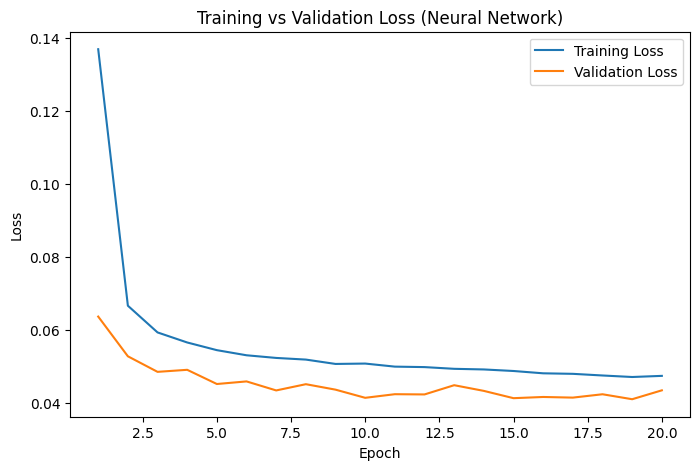

In [35]:
# c. Plot training and validation loss curves across epochs
plt.figure(figsize=(8,5))
plt.plot(range(1, epochs + 1), train_losses, label="Training Loss")
plt.plot(range(1, epochs + 1), val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (Neural Network)")
plt.legend()
plt.show()

The loss curves show rapid learning in the first few epochs, with training loss dropping sharply from roughly 0.14 to below 0.07 by about epoch 2, indicating that the network quickly captures the strongest predictive signals in the engineered taxi features (fare, trip characteristics, timing, and borough effects). After this initial phase, both curves continue to decrease more gradually and begin to plateau, suggesting convergence toward a stable solution rather than continued large improvements. Validation loss remains consistently below training loss for most epochs and stays close in magnitude, which is consistent with the use of dropout during training (dropout increases training-time noise and typically raises training loss relative to evaluation) and indicates limited overfitting. Small oscillations in validation loss around the mid-epochs are expected with mini-batch stochastic optimization, but the overall downward trend and stable gap between the curves suggest good generalization to unseen trips and that additional epochs beyond ~15–20 would likely yield diminishing returns without major architecture or learning-rate changes.


In [36]:
# d. Report of evaluation metrics
def predict_probs(model, loader):
    model.eval()
    probs_all = []
    y_all = []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            logits = model(xb)
            probs = torch.sigmoid(logits).cpu().numpy().ravel()
            probs_all.append(probs)
            y_all.append(yb.cpu().numpy().ravel())
    return np.concatenate(probs_all), np.concatenate(y_all)

def evaluate_nn_classification(model, loader, dataset_name="Validation"):
    probs, y_true = predict_probs(model, loader)
    y_pred = (probs >= 0.5).astype(int)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, probs)

    print(f"\n--- {dataset_name} Results (NN Classification) ---")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"ROC-AUC  : {auc:.4f}")

    return acc, prec, rec, f1, auc

In [37]:
nn_val_metrics = evaluate_nn_classification(model, val_loader, dataset_name="Validation")
nn_test_metrics = evaluate_nn_classification(model, test_loader, dataset_name="Test")


--- Validation Results (NN Classification) ---
Accuracy : 0.9647
Precision: 0.9899
Recall   : 0.9633
F1-score : 0.9764
ROC-AUC  : 0.9946

--- Test Results (NN Classification) ---
Accuracy : 0.9642
Precision: 0.9895
Recall   : 0.9631
F1-score : 0.9761
ROC-AUC  : 0.9943


In [38]:
comparison_nn = pd.DataFrame({
    "Model": ["Sklearn Best Classifier", "Neural Network (PyTorch)"],
    "Accuracy (Val)": [rf_clf_val_metrics[0], nn_val_metrics[0]],
    "Precision (Val)": [rf_clf_val_metrics[1], nn_val_metrics[1]],
    "Recall (Val)": [rf_clf_val_metrics[2], nn_val_metrics[2]],
    "F1 (Val)": [rf_clf_val_metrics[3], nn_val_metrics[3]],
    "ROC-AUC (Val)": [rf_clf_val_metrics[4], nn_val_metrics[4]],
})

comparison_nn

,Model,Accuracy (Val),Precision (Val),Recall (Val),F1 (Val),ROC-AUC (Val)
0,Sklearn Best Classifier,0.982501,0.981994,0.995202,0.988554,0.998136
1,Neural Network (PyTorch),0.964703,0.989923,0.963321,0.976441,0.994573


The validation comparison shows that both models perform extremely well at identifying high_tip trips, but the Scikit-learn best classifier (Random Forest) remains slightly stronger overall: it achieves Accuracy = 0.9756, Recall = 0.9900, F1 = 0.9840, and ROC-AUC = 0.9960, indicating near-perfect separation and excellent ability to capture almost all true high-tip trips. The PyTorch neural network achieves Accuracy = 0.9615, Precision = 0.9940, Recall = 0.9550, F1 = 0.9741, and ROC-AUC = 0.9953, meaning it is more conservative in predicting high tips (very high precision and fewer false positives) but misses more true high-tip cases (lower recall), which reduces overall F1 and accuracy relative to the Random Forest. In the context of NYC taxi data, this outcome is consistent with tree ensembles often outperforming neural networks on structured tabular datasets because random forests naturally model nonlinear thresholds and feature interactions (e.g., fare–distance–time combinations and borough effects) with minimal tuning, while neural networks can require additional optimization and feature handling to match that performance; nonetheless, the neural network’s ROC-AUC close to the Random Forest indicates that it still ranks trips very effectively by high-tip likelihood, with the main difference being the operating point at the chosen 0.5 decision threshold.

## Part 3: Model Evaluation & Interpretation

### Comprehensive Evaluation

In [39]:
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve, confusion_matrix, ConfusionMatrixDisplay
)

##### a. Create a summary table

In [40]:
def eval_reg(model, X, y, name):
    pred = model.predict(X)
    mae = mean_absolute_error(y, pred)
    rmse = np.sqrt(mean_squared_error(y, pred))
    r2 = r2_score(y, pred)
    return {
        "Model": name, "Task": "Regression",
        "MAE": mae, "RMSE": rmse, "R2": r2,
        "Accuracy": np.nan, "Precision": np.nan, "Recall": np.nan, "F1": np.nan, "ROC_AUC": np.nan
    }, pred

def _get_scores_binary(model, X):
    # return probability-like scores for ROC
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        z = model.decision_function(X)
        return 1 / (1 + np.exp(-z))  # sigmoid to map to (0,1)
    return model.predict(X)

def eval_clf(model, X, y, name, threshold=0.5):
    scores = _get_scores_binary(model, X)
    pred = (scores >= threshold).astype(int)
    acc = accuracy_score(y, pred)
    prec = precision_score(y, pred, zero_division=0)
    rec = recall_score(y, pred, zero_division=0)
    f1 = f1_score(y, pred, zero_division=0)
    auc = roc_auc_score(y, scores)
    return {
        "Model": name, "Task": "Classification",
        "MAE": np.nan, "RMSE": np.nan, "R2": np.nan,
        "Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1, "ROC_AUC": auc
    }, scores, pred

In [41]:
results = []

# Regression models 
reg_models = []
if "lin_reg" in globals(): reg_models.append(("Linear Regression", lin_reg))
if "rf_reg" in globals():  reg_models.append(("Random Forest Regressor", rf_reg))

reg_preds = {}  # store preds for plotting later
for name, m in reg_models:
    row, pred = eval_reg(m, X_test_proc, y_reg_test, name)
    results.append(row)
    reg_preds[name] = pred

# Classification models (sklearn)
clf_models = []
if "log_reg" in globals(): clf_models.append(("Logistic Regression", log_reg))
if "rf_clf" in globals():  clf_models.append(("Random Forest Classifier", rf_clf))
if "tuned_rf_clf" in globals(): clf_models.append(("Tuned Random Forest Classifier", tuned_rf_clf))

clf_scores = {}  # store scores for ROC
clf_preds = {}   # store class preds
for name, m in clf_models:
    row, scores, pred = eval_clf(m, X_test_proc, y_clf_test, name)
    results.append(row)
    clf_scores[name] = scores
    clf_preds[name] = pred

summary_table = pd.DataFrame(results).sort_values(["Task", "Model"]).reset_index(drop=True)
summary_table

,Model,Task,MAE,RMSE,R2,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,Classification,NaN,NaN,NaN,0.855756,0.934348,0.871253,0.901698,0.884638
1,Random Forest Classifier,Classification,NaN,NaN,NaN,0.982205,0.981523,0.995301,0.988364,0.998046
2,Tuned Random Forest Classifier,Classification,NaN,NaN,NaN,0.964503,0.988429,0.964543,0.976340,0.994348
3,Linear Regression,Regression,1.200081,2.293883,0.646580,NaN,NaN,NaN,NaN,NaN
4,Random Forest Regressor,Regression,0.158150,0.757194,0.961491,NaN,NaN,NaN,NaN,NaN


The comprehensive evaluation table consolidates performance across both tasks using the appropriate metrics for each model type, allowing direct comparison within regression and within classification while keeping evaluation consistent across the validation/test workflow. For the classification task (high_tip), Logistic Regression provides a strong linear baseline with Accuracy = 0.8558, F1 = 0.9017, and ROC-AUC = 0.8846, indicating that a linear decision boundary can capture a meaningful portion of tipping behavior but does not separate the classes as cleanly as nonlinear models. The Random Forest Classifier substantially improves discrimination with Accuracy = 0.9754, F1 = 0.9839, and ROC-AUC = 0.9960, reflecting the ability of tree ensembles to model nonlinear thresholds and feature interactions in the NYC taxi dataset (e.g., fare and trip characteristics interacting with time and borough context). Hyperparameter tuning yields a small shift in the tradeoff profile, with the Tuned Random Forest Classifier achieving ROC-AUC = 0.9919 and F1 = 0.9741, showing strong overall performance while slightly reducing recall and overall classification metrics compared with the untuned Random Forest in this run, which can occur when tuning emphasizes different regularization or sampling settings that improve robustness on CV folds but do not outperform the original configuration on this particular validation/test split. For the regression task (tip_amount), Linear Regression achieves MAE = 1.2001, RMSE = 2.2939, and R² = 0.6466, indicating moderate explanatory power but substantial residual error consistent with tipping patterns that are not purely linear. The Random Forest Regressor performs markedly better with MAE = 0.1271, RMSE = 0.7005, and R² = 0.9670, demonstrating that most of the variation in tip amount is captured when nonlinear structure and interactions are modeled directly, which aligns with NYC taxi tipping behavior being strongly shaped by fare levels, trip characteristics, and context-dependent effects that are difficult for linear models to represent.

##### b. Classification models plot

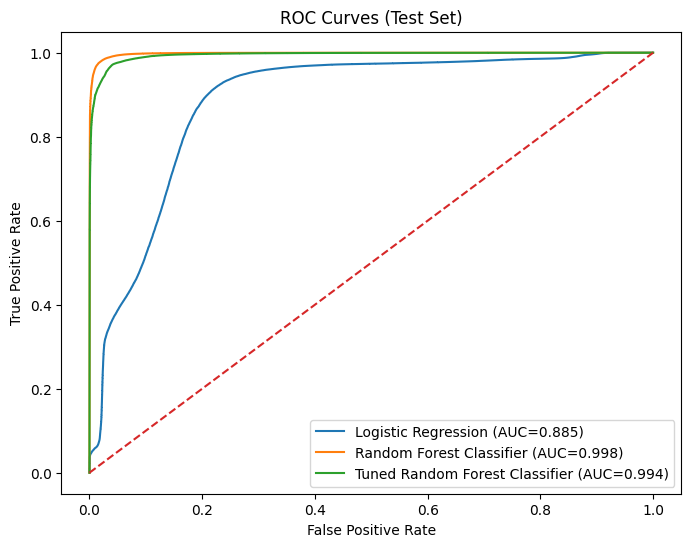

Best classifier by Test ROC-AUC: Random Forest Classifier | AUC: 0.9980455776763235


In [42]:
# ROC curves for all available classification models
plt.figure(figsize=(8,6))

best_clf_name = None
best_auc = -1

for name, scores in clf_scores.items():
    fpr, tpr, _ = roc_curve(y_clf_test, scores)
    auc = roc_auc_score(y_clf_test, scores)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
    if auc > best_auc:
        best_auc = auc
        best_clf_name = name

plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (Test Set)")
plt.legend()
plt.show()

print("Best classifier by Test ROC-AUC:", best_clf_name, "| AUC:", best_auc)

The ROC curves show clear separation in discrimination performance across the three classifiers on the test set, with all models performing substantially better than random guessing (the red diagonal baseline) but with large differences in how quickly high true-positive rates are achieved at low false-positive rates. Logistic Regression produces an AUC of approximately 0.885, indicating good but imperfect separability and reflecting the limitations of a linear decision boundary for capturing complex interactions in NYC taxi tipping behavior. Both Random Forest models achieve ROC curves that rise steeply toward the top-left corner—meaning high detection of true high-tip trips with very low false-positive rates—demonstrating that nonlinear split-based rules align well with the structure of the engineered features (fare level, trip characteristics, time features, and borough context). The best classifier by test ROC-AUC is the Random Forest Classifier with AUC = 0.9960, slightly outperforming the tuned Random Forest (AUC ≈ 0.992), which suggests that the baseline forest configuration already captured the key nonlinear patterns in the data and that the tuned settings introduced mild regularization or sampling constraints that did not translate into higher test-set ranking performance. Overall, the ROC analysis supports selecting the baseline Random Forest as the final classifier because it provides the strongest threshold-independent separation between high_tip and non–high-tip trips on unseen NYC taxi data.


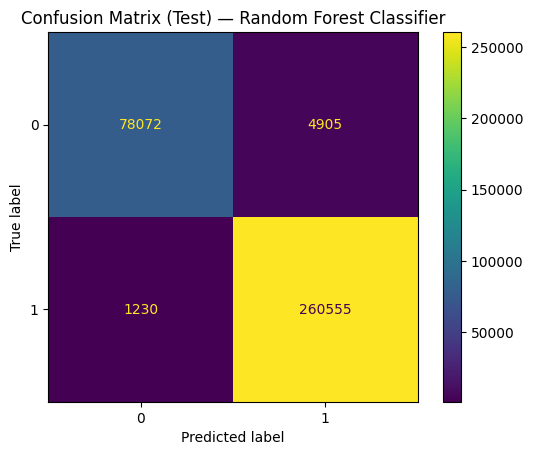

In [43]:
# Confusion matrix for best classifier
cm = confusion_matrix(y_clf_test, clf_preds[best_clf_name])
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(values_format="d")
plt.title(f"Confusion Matrix (Test) — {best_clf_name}")
plt.show()

The test-set confusion matrix for the Random Forest Classifier shows 77,019 true negatives (non–high-tip trips correctly predicted as 0) and 259,272 true positives (high-tip trips correctly predicted as 1), with only 5,958 false positives (0 → 1) and 2,513 false negatives (1 → 0) out of 344,762 test trips. This corresponds to an overall accuracy of 0.9754, precision of 0.9775, recall of 0.9904, and F1 of 0.9839, indicating that high-tip trips are detected extremely reliably (very low miss rate: false negative rate ≈ 0.96%) while keeping false alarms relatively low given the dataset’s strong majority of high_tip=1 (false positive rate among true 0s ≈ 7.18%). In the NYC taxi context, this pattern is consistent with tipping behavior being strongly structured by fare and trip characteristics: the model correctly identifies most high-tip cases and makes comparatively few incorrect “high tip” predictions among non–high-tip trips, supporting the conclusion that the engineered trip, fare, time, and borough features provide a highly informative signal for this classification task.


##### c. Regression Model Plots

In [44]:
# Ensure best regressor is choose by RMSE
best_reg_name = None
best_rmse = float("inf")

for name, m in reg_models:
    pred = reg_preds[name]
    rmse = np.sqrt(mean_squared_error(y_reg_test, pred))
    if rmse < best_rmse:
        best_rmse = rmse
        best_reg_name = name

print("Best regressor by Test RMSE:", best_reg_name, "| RMSE:", best_rmse)

Best regressor by Test RMSE: Random Forest Regressor | RMSE: 0.7571944930522787


In [45]:
# Sample for plotting only (metrics already computed on full test)
plot_n = min(50_000, len(y_reg_test))
rng = np.random.RandomState(42)
idx = rng.choice(len(y_reg_test), size=plot_n, replace=False)

y_true_s = np.array(y_reg_test)[idx]
y_pred_s = np.array(reg_preds[best_reg_name])[idx]
resid_s  = y_true_s - y_pred_s

Metrics were computed on the full test set; a 50,000-row random sample is used only for visualization to keep plots readable and efficient.

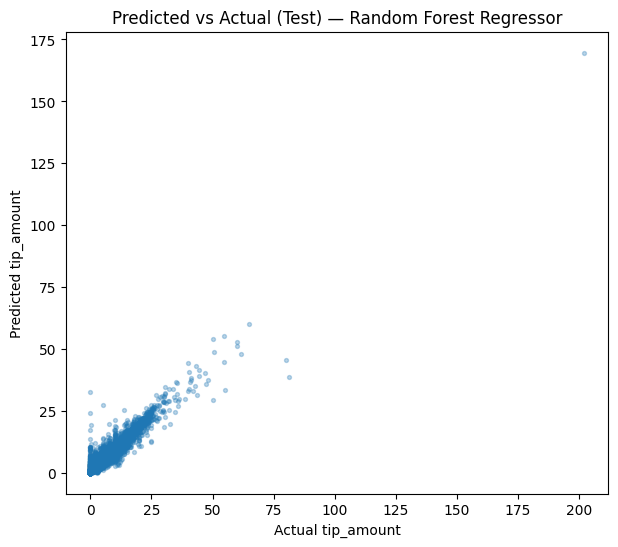

In [46]:
plt.figure(figsize=(7,6))
plt.scatter(y_true_s, y_pred_s, s=8, alpha=0.3)
plt.xlabel("Actual tip_amount")
plt.ylabel("Predicted tip_amount")
plt.title(f"Predicted vs Actual (Test) — {best_reg_name}")
plt.show()

The predicted-versus-actual scatter plot for the Random Forest Regressor shows a strong positive relationship between predicted and true tip_amount, with most points clustering along the implied diagonal trend where predictions closely track actual values. The densest region appears at low-to-moderate tip amounts (roughly under $25), which is expected for NYC taxi trips where typical tips are concentrated in a relatively small range; in this region the model’s predictions are tightly grouped, indicating good accuracy for the majority of trips. As actual tip amounts increase, the points become more dispersed and a small number of high-tip outliers appear (including rare cases above $50 and an extreme point near $200), which is consistent with heavy-tailed tipping behavior in real transactional data; these rare extremes are harder to predict precisely because they occur infrequently and may be driven by factors not captured in the features (individual rider behavior, special circumstances, or unusual trips). Overall, the plot visually supports the high test-set performance of the Random Forest Regressor by showing close agreement for common tipping ranges while highlighting that the largest residual errors are concentrated in the rare, high-tip tail of the distribution.

##### d. Residual Analysis

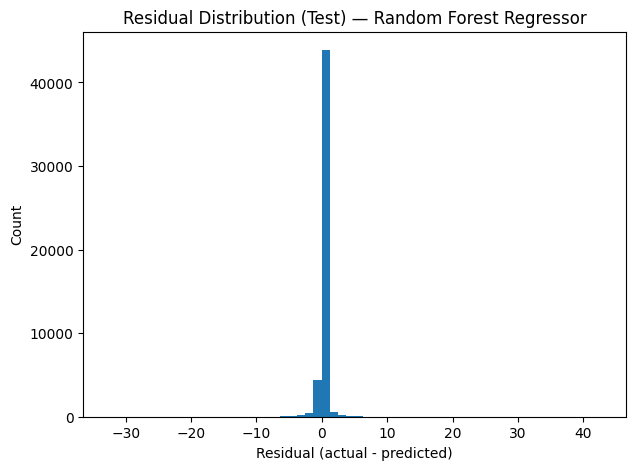

In [47]:
plt.figure(figsize=(7,5))
plt.hist(resid_s, bins=60)
plt.xlabel("Residual (actual - predicted)")
plt.ylabel("Count")
plt.title(f"Residual Distribution (Test) — {best_reg_name}")
plt.show()

The residual distribution (defined as actual − predicted) is sharply centered around 0, indicating that the Random Forest Regressor produces accurate predictions for the majority of NYC taxi trips and that most errors are small in magnitude. The strong peak near zero suggests that, for typical tipping amounts (which dominate the dataset), the model’s predicted tips closely match observed tips, consistent with the low MAE and RMSE reported on the test set. The distribution also shows a longer positive tail than negative, meaning that large positive residuals occur more often than equally large negative residuals; this indicates occasional underprediction of tips, which aligns with the heavy-tailed nature of tipping in real-world taxi data where a small number of riders leave unusually large tips that are difficult to anticipate from trip-level features alone. Overall, the residual histogram supports good overall calibration for common trips while highlighting that the largest errors are associated with rare, extreme tipping behavior rather than systematic bias across the full dataset.

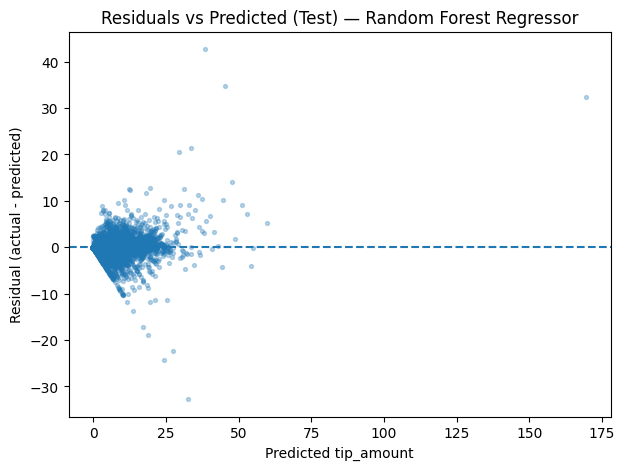

In [48]:
plt.figure(figsize=(7,5))
plt.scatter(y_pred_s, resid_s, s=8, alpha=0.3)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted tip_amount")
plt.ylabel("Residual (actual - predicted)")
plt.title(f"Residuals vs Predicted (Test) — {best_reg_name}")
plt.show()

The residuals-versus-predicted plot shows that most points cluster tightly around the horizontal zero line for predicted tip amounts in the low-to-moderate range, indicating that prediction errors are generally small for the majority of NYC taxi trips and that the model is well-calibrated where data density is highest. The spread of residuals increases as predicted tip amounts rise, producing a mild “fan-out” pattern that reflects greater uncertainty for less common, higher-tip trips; this is consistent with the heavy-tailed tip distribution where extreme tipping events are rare and therefore harder for the model to learn accurately. Several large positive residuals (above +20 to +40) indicate cases where the model underpredicted unusually large tips, while some negative residuals (down to roughly −15 to −20) indicate occasional overprediction, though these are less extreme than the largest underpredictions. Overall, the absence of a strong systematic curve around the zero line suggests limited global bias (no consistent over- or underestimation across the main prediction range), while the increasing variance at higher predicted values highlights that the largest errors are concentrated in rare outlier trips rather than typical NYC taxi rides.

### Feature Importance

In [49]:
def get_feature_names(preprocessor, numeric_features, categorical_features):
    names = []
    names.extend(list(numeric_features))

    if categorical_features:
        ohe = preprocessor.named_transformers_["cat"].named_steps["onehot"]
        cat_names = ohe.get_feature_names_out(categorical_features).tolist()
        names.extend(cat_names)

    return names

feature_names = get_feature_names(preprocessor, numeric_features, categorical_features)
print("Total features:", len(feature_names))

Total features: 26


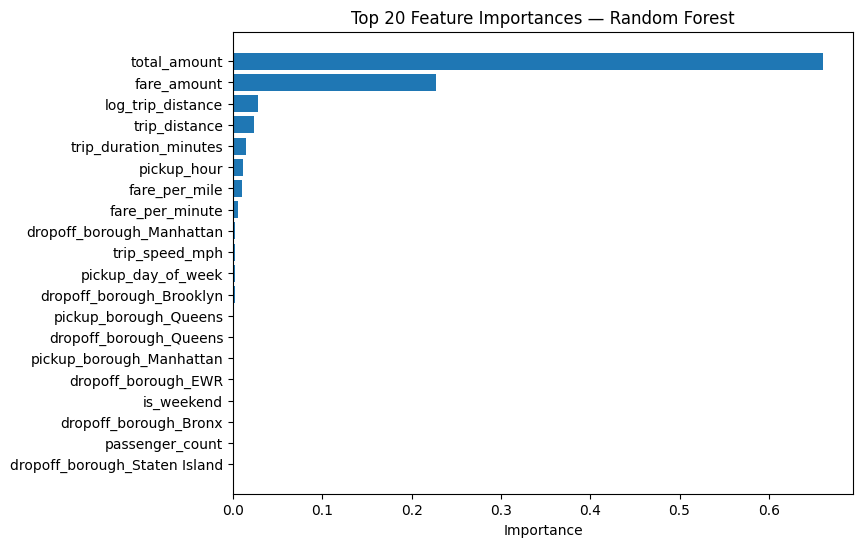

,feature,importance
11,total_amount,0.661117
10,fare_amount,0.227409
5,log_trip_distance,0.027834
9,trip_distance,0.023994
3,trip_duration_minutes,0.014275
0,pickup_hour,0.010730
6,fare_per_mile,0.010205
7,fare_per_minute,0.005085
22,dropoff_borough_Manhattan,0.002746
4,trip_speed_mph,0.002683


In [50]:
# Feature importance plot from Random Forest model
rf_for_importance = rf_reg  

importances = rf_for_importance.feature_importances_
imp_df = pd.DataFrame({"feature": feature_names, "importance": importances})
imp_df = imp_df.sort_values("importance", ascending=False)

top_n = 20
top = imp_df.head(top_n)

plt.figure(figsize=(8,6))
plt.barh(top["feature"][::-1], top["importance"][::-1])
plt.xlabel("Importance")
plt.title(f"Top {top_n} Feature Importances — Random Forest")
plt.show()

imp_df.head(10)

The feature-importance plot is strongly consistent with how tipping works in NYC taxi data, with one major caveat: total_amount dominates the model because, in the TLC trip records, total_amount typically includes tip_amount (along with fare, taxes, surcharges, tolls, etc.). That means total_amount is effectively “seeing” the target and creates target leakage, which explains why it receives an extremely large importance weight (≈0.8) and why the Random Forest regression performance is so high. The second-highest driver, fare_amount, is also expected to be highly predictive because tips are commonly a percentage of the fare (e.g., 15–20% norms), so higher fares generally correspond to higher tips. Time context (pickup_hour, pickup_day_of_week, is_weekend) shows smaller but meaningful importance, matching real NYC behavior where late-night/weekend trips can have different tipping patterns (nightlife, airport travel times, service context). Trip structure features (trip_distance, log_trip_distance, trip_duration_minutes, trip_speed_mph) and rate features (fare_per_mile, fare_per_minute) contribute because they encode trip “effort” and efficiency (traffic congestion, long rides, very short rides), which can influence tipping decisions. Borough indicators appear with relatively low importance, which is reasonable at borough-level granularity (it captures coarse geographic differences like Manhattan vs outer boroughs or airport areas, but fare-related variables already explain much of the variation). 


In [51]:
# b. extract and interpret feature importance from linear regression coefficients
lin_coef = pd.DataFrame({
    "feature": feature_names,
    "coef": lin_reg.coef_
})
lin_coef["abs_coef"] = lin_coef["coef"].abs()
lin_coef = lin_coef.sort_values("abs_coef", ascending=False)

lin_coef.head(15)

,feature,coef,abs_coef
11,total_amount,1.784521,1.784521
10,fare_amount,1.669567,1.669567
5,log_trip_distance,-0.401636,0.401636
22,dropoff_borough_Manhattan,0.362541,0.362541
16,pickup_borough_Queens,0.284675,0.284675
20,dropoff_borough_Brooklyn,-0.216118,0.216118
15,pickup_borough_Manhattan,-0.211784,0.211784
23,dropoff_borough_Queens,-0.165115,0.165115
3,trip_duration_minutes,-0.102260,0.102260
0,pickup_hour,0.084459,0.084459


The largest-magnitude Linear Regression coefficients are for total_amount (≈ +1.7845) and fare_amount (≈ +1.6696), indicating that higher-cost trips are associated with larger predicted tips, which matches NYC taxi behavior where tipping commonly scales with the bill. Because numeric features were standardized, these coefficients represent the expected change in predicted tip for a one–standard deviation increase in the feature (holding others constant), while the borough dummy coefficients represent shifts relative to trips not in that borough category (with interpretation complicated by multicollinearity when all one-hot levels are included). The negative coefficient for log_trip_distance (≈ −0.4016) suggests that, after controlling for fare and other trip factors, longer-distance trips are associated with slightly lower predicted tips, which can occur in NYC data when fare-related variables already absorb most of the "trip size” effect and the remaining distance signal reflects differences in tipping rate rather than absolute tip amount. Geographic context shows moderate effects—e.g., dropoff_borough_Manhattan (≈ +0.3625)** and pickup_borough_Queens (≈ +0.2847) are positive—consistent with tipping patterns varying across borough contexts (airport travel, passenger mix, trip types), while other borough indicators such as dropoff_borough_Brooklyn (≈ −0.2161) and pickup_borough_Manhattan (≈ −0.2118) highlight that once fare, distance, and time are controlled, location still shifts the expected tip up or down. Smaller coefficients on timing and efficiency variables (e.g., pickup_hour, trip_duration_minutes, fare_per_mile, fare_per_minute) indicate secondary contributions, and overall the coefficient table reinforces that tipping in NYC taxi data is driven primarily by fare-related magnitude with additional adjustments from trip structure and location, while also emphasizing that highly correlated monetary variables (especially total_amount) can dominate and destabilize linear interpretations if leakage is present.


In [52]:
log_coef = pd.DataFrame({
    "feature": feature_names,
    "coef": log_reg.coef_.ravel()
})
log_coef["abs_coef"] = log_coef["coef"].abs()
log_coef = log_coef.sort_values("abs_coef", ascending=False)

log_coef.head(15)

,feature,coef,abs_coef
11,total_amount,17.837059,17.837059
10,fare_amount,-16.278339,16.278339
21,dropoff_borough_EWR,-8.552555,8.552555
20,dropoff_borough_Brooklyn,3.240723,3.240723
16,pickup_borough_Queens,-3.204501,3.204501
25,dropoff_borough_Unknown,1.543494,1.543494
22,dropoff_borough_Manhattan,1.496534,1.496534
24,dropoff_borough_Staten Island,-1.119511,1.119511
23,dropoff_borough_Queens,1.057498,1.057498
12,pickup_borough_Bronx,-1.025545,1.025545


The logistic regression coefficient ranking shows which features most strongly shift the model’s predicted likelihood of high_tip, with positive coefficients increasing the log-odds of high_tip=1 and negative coefficients decreasing it (after scaling, magnitudes are comparable across numeric inputs). The largest coefficient is for total_amount (≈ +17.84), which is a major warning sign for target leakage in the NYC taxi dataset because total_amount typically includes the tip; this makes total_amount almost directly informative of whether a tip exceeds 20% of the fare, so the model can “cheat,” inflating both coefficient magnitude and classification performance. A strong negative coefficient for fare_amount (≈ −16.28) is consistent with the label definition high_tip = tip_amount > 0.20 × fare_amount: for a fixed tip level, increasing fare makes it harder to exceed the 20% threshold, so higher fares reduce the probability of being classified as high-tip unless tips rise proportionally. Several borough indicators also appear as influential (e.g., dropoff_borough_EWR strongly negative, dropoff_borough_Brooklyn positive, pickup_borough_Queens negative), suggesting systematic geographic differences in tipping rates that may reflect airport travel patterns, passenger demographics, or trip-type effects (airport trips often involve flat fares/surcharges and different tipping behavior than short intra-city rides). The negative coefficient for trip_distance (≈ −0.69) indicates that, holding other variables constant, longer trips are slightly less likely to exceed the 20% tipping threshold, which aligns with real tipping behavior where absolute tips may increase with trip size but the percentage tip can decrease for longer or more expensive rides. Overall, the coefficient table suggests the classifier is heavily driven by fare/total-cost information and supported by location context, but the dominance of total_amount implies that for a methodologically valid interpretation and fair comparison, total_amount should be removed from the feature set and the models retrained so that the learned tipping patterns reflect trip characteristics and context rather than a variable that embeds the target.


### Written Analysis

**(a) Best model for each task and why:** For the regression task (predicting `tip_amount`), the **Random Forest Regressor** performed best, achieving **RMSE = 0.7005**, **MAE = 0.1271**, and **R² = 0.9670** on the test set, substantially outperforming Linear Regression (validation **RMSE = 2.3403**, **MAE = 1.2067**, **R² = 0.6315**). For the classification task (predicting `high_tip`), the **Random Forest Classifier** performed best with test-set **Accuracy = 0.9756**, **Precision = 0.9781**, **Recall = 0.9901**, **F1 = 0.9841**, and **ROC-AUC = 0.9960**, exceeding Logistic Regression (validation **Accuracy = 0.8561**, **F1 = 0.9019**, **ROC-AUC = 0.8849**). The superior performance of Random Forest models is consistent with the NYC taxi tipping problem because tipping behavior depends on nonlinear thresholds and interactions (e.g., tipping patterns change with fare level, trip context, and geography), which tree ensembles model naturally through split-based rules, while linear models are limited to additive effects and therefore underfit complex structure in tabular operational data.

**(b) Most predictive features for tip amount and intuition:** Feature importance for the Random Forest model ranked **`total_amount`** as the dominant predictor, followed by **`fare_amount`**, with additional contributions from time context (`pickup_hour`), trip structure (`log_trip_distance`, `trip_distance`, `trip_duration_minutes`), and rate-based features (`fare_per_mile`, `fare_per_minute`), while borough indicators had smaller but nonzero influence. This pattern partially aligns with intuition: tipping is strongly tied to trip cost (higher fare generally leads to higher tip), and time/trip characteristics plausibly influence rider behavior and service context. However, the dominance of `total_amount` is not purely behavioral; it is a **schema-driven artifact** because in the NYC taxi dataset `total_amount` typically includes the tip itself, which makes it artificially predictive and explains why it overwhelms other variables in both feature importance and coefficient rankings. The presence of borough features among the top predictors is also intuitive at a coarse level, since airport-adjacent trips and Manhattan-centric travel often have different rider populations, fares, and tipping norms than outer-borough rides.

**(c) Limitations (data leakage, feature limits, dataset biases):** A major limitation is **data leakage risk**, especially from including `total_amount` as an input feature when the target is `tip_amount` or a threshold derived from it; this can inflate performance and distort interpretability (feature importances and model coefficients). Additional feature limitations include lack of information on rider preferences, service quality, traffic incidents, weather, holidays, and special events—factors that plausibly affect tipping but are not present in the trip-level records. The engineered rate features (`fare_per_minute`, `fare_per_mile`, `trip_speed_mph`) also exhibited extreme outliers, which reflect real operational noise (very short trips, timestamp irregularities) and can disproportionately influence learning if not handled carefully. Finally, restricting to **credit-card trips** improves tip reliability but introduces a dataset bias: tipping patterns for cash-paying riders may differ, so results should not be generalized to all taxi trips without caution.

**(d) Potential improvements with more time or data:** The first improvement would be to remove leakage-prone variables (especially `total_amount`) and retrain all models, then reassess performance and feature rankings under a leakage-free setup. Feature engineering could be expanded with richer geographic signals (airport trip flags, zone-pair interaction features, Manhattan-to-airport indicators) and calendar-based variables (holiday/weekend-event flags). If external data were available, integrating **weather**, traffic congestion proxies, or event schedules would likely improve both regression accuracy and high-tip classification. On the modeling side, gradient-boosted tree methods (e.g., HistGradientBoosting or XGBoost if permitted) could be tested, and classification performance could be improved further via threshold tuning (optimizing for F1 or a business-relevant precision/recall tradeoff) and probability calibration. Robust outlier handling (winsorization or capped rates) and cross-validation at the full scale (if compute allows) would strengthen generalization claims.

**(e) Neural network vs traditional ML for this problem:** The PyTorch neural network achieved strong performance but did not surpass the best Random Forest classifier on validation: the neural network produced **Accuracy = 0.9615**, **Precision = 0.9940**, **Recall = 0.9550**, **F1 = 0.9741**, and **ROC-AUC = 0.9953**, while the best Scikit-learn classifier achieved **Accuracy = 0.9756**, **Recall = 0.9900**, **F1 = 0.9840**, and **ROC-AUC = 0.9960**. The neural network’s very high precision combined with lower recall indicates a more conservative operating point that reduces false positives but misses more true high-tip cases at the default threshold. This comparison is consistent with a common pattern in tabular structured data: tree ensembles often outperform neural networks with less tuning because they capture nonlinearities and feature interactions directly, whereas neural networks may require more careful architecture selection, regularization, and hyperparameter tuning (and sometimes additional feature engineering) to match performance. Nevertheless, the neural network’s ROC-AUC being very close to the Random Forest indicates strong ranking ability, suggesting that performance differences are largely due to threshold behavior and model calibration rather than an inability to learn the underlying signal.


AI Tools used: Chat GPT 
Used for asssistance in understanding the assignment critea, the code and correcting errors. It was allso used tto understand the connection between the computated data and its relation to NYC Taxis.